We are attempting to obtain a parametrized two-qubit $CZ_{\phi}$ gate (same as the $CPHASE$ gate). 

To start off we run/import some code that is used both for single-angle optimizations and multi-angle optimizations.

In [2]:
import torch 
from decimal import Decimal
from schsolve import neural_trainer, schsolver 
import schsolve
import torchdiffeq as tdf 
import cst_n_fn as cfn 
import matplotlib.pyplot as plt 
import const_czphi as czphi 
import numpy as np 
# import pytorch_warmup as warmup 
from const_czphi import reduce_r_dim_2q_vector, correction_1q

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device = "cpu"

print(device)
    
# **** training function below ****
# Note that this has to be coded separately for each use case 

def trainer(neural_model, nn_solver_1, nn_solver_2, input_tensor, scheduler, epoch, init_matrix, multiplier = 2.0, print_ = True):
    
    neural_model.train()
    nn_solver_1.zero_grad()
    nn_solver_2.zero_grad()
    
    nn_time_output = (neural_model(input_tensor).select(1,0))
    pred_outputs_detuning = nn_time_output*(neural_model.range_detuning[1] - neural_model.range_detuning[0]) + neural_model.range_detuning[0]
        
    czphi.instance.hamiltonian.rabi_tensored["pulse 0"] \
    = czphi.instance.hamiltonian.rabi_tensored["pulse 1"] \
    = cfn.const_then_zero_tensor(cfn.rabi, neural_model.gatetime_prediction)

    czphi.instance.hamiltonian.det_tensored["pulse 0"] \
    = czphi.instance.hamiltonian.det_tensored["pulse 1"] \
    = czphi.list_to_fn_tensor_var_gatetime(pred_outputs_detuning, neural_model.gatetime_prediction, czphi.time_steps)    
    
    time_arr_ = torch.linspace(0, 1.0, czphi.time_steps, device = device)*neural_model.gatetime_prediction.max()
    
    # * code below evolves the Hamiltonian with time-dependent controls and computes the state in the subspace of 0s and 1s

    sol_intrm = reduce_r_dim_2q_vector(tdf.odeint(czphi.instance,\
                                init_matrix, time_arr_, 
                                #method = 'dopri5', rtol = 1e-4, atol = 1e-4, \
                                method = 'rk4', \
                                )[-1], angle_batch = czphi.angle_batch)

    solution = correction_1q(sol_intrm, angle_batch = czphi.angle_batch) 

    infidelity_term = cfn.unitary_infidelity_array(solution, \
        cfn.czp_gate_stack(input_tensor/neural_model.scale_factor + neural_model.offset), nqbits = 2)  
    time_term = multiplier*torch.mean(neural_model.gatetime_prediction)

    dict_ = {"time term": time_term.item(), "infidelity term": infidelity_term.item(),
                "gatetime mean.": torch.mean(neural_model.gatetime_prediction)}

    loss_instance = infidelity_term + time_term 
    
    neural_model.debug_gradient_time.retain_grad()
    nn_time_output.retain_grad()
    loss_instance.backward()
    nn_solver_2.step()
    nn_solver_1.step()
    
    if scheduler[0] == True:
        scheduler[2].step()
        scheduler[1].step()
    
    if epoch%50 == 0 and print_ == True:  
        
        print(neural_model.gatetime_prediction.max()*cfn.rabi)
        
        print("Epoch {}: Loss = {:.2E}".format(epoch, Decimal(loss_instance.cpu().detach().numpy().item())))
        
        print(dict_)
        print('gradient time!')
        print(sum(neural_model.debug_gradient_time.grad))
        print('gradient control!')
    
    return solution.cpu().detach().numpy(), loss_instance.item(), dict_

def scale_and_offset(angle_arr, network):
    
    # * This function scales the angle by some factor (useful for small angles)
    # * And also subtracts an offset s.t. the mean = 0 

    a = (angle_arr - network.offset)*network.scale_factor 

    return a 

cpu


Note: the code cell right below is to to demonstrate (and potentially utilize) file handling i.e. loading a pre-trained NN. You can comment out the lines if you just want to train a randomly initialized NN. The current net being loaded is the 'final' i.e. converged net for the range $[0.5\pi, \pi]$. 

In [3]:
filename = "data/final_models/5e-5pi_to_0.05pi"
load_dict = torch.load(filename)

composite_network = load_dict["network"].to(device)

composite_network._aux_tensor = composite_network._aux_tensor.to(device)
nn_solver_1 = load_dict["solver"][0]
nn_solver_2 = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)


FileNotFoundError: [Errno 2] No such file or directory: 'data/final_models/5e-5pi_to_0.05pi'

In [ ]:
# NOTE: The below commented code was used to initialize a random weight NN s.t. it returns 
# a desired value at a certain angle. For instance, we know the optimal time at angle pi, so 
# we can initialize the NN s.t. it returns this time from the start. 

'''
composite_network = 0.0
t_pred_low = torch.tensor(0.0)
t_pred_high = torch.tensor(0.0)
#t_pred_
angle_list = torch.linspace(0.1*torch.pi, 0.5*torch.pi, 101).reshape(101, 1)

time_constr_high = [6.7/cfn.rabi, 6.9/cfn.rabi]
time_constr_low = [4.8/cfn.rabi, 5.2/cfn.rabi]

while ((t_pred_low.item() > time_constr_low[1] or t_pred_low.item() < time_constr_low[0])\
  or (t_pred_high.item() > time_constr_high[1] or t_pred_high.item() < time_constr_high[0])):

    composite_network = czphi.neural_trainer_time_optimal_cz(nl1 = 2, nu1 = 60, nl2 = 10, \
    nu2 = 300, beta_control = 2.15, time_bounds = [2.05/cfn.rabi, 7.0/cfn.rabi], \
      beta_time = 2.15, range_detuning = [-2.0*cfn.rabi, 2.0*cfn.rabi])
    composite_network(angle_list)    
    tb = composite_network.time_bounds 
    t_pred_low = composite_network.gatetime_prediction[0]
    #print(t_pred_low*cfn.rabi)
    t_pred_high = composite_network.gatetime_prediction[-1]
    #print(t_pi_pred*cfn.rabi)
    #(tb[1] - tb[0]) + tb[0] 
''' 

In [4]:
# NOTE: Comment out the composite_network lines below if you want to train a pre-loaded NN 
# that you loaded above 

composite_network = czphi.neural_trainer_time_optimal_cz(nl1 = 3, nu1 = 45, nl2 = 10, \
   nu2 = 300, beta_control = 1.55, time_bounds = [3.0/cfn.rabi, 8.5/cfn.rabi],\
      range_detuning = [-2.0*cfn.rabi, 2.0*cfn.rabi], beta_time = 1.8, mode = 'tanh',\
         scale_factor = 1e0)

#composite_network.angle_range = [5e-5*torch.pi, 0.1*torch.pi] 
#composite_network.angle_range = np.array([5e-5*torch.pi, 0.05*torch.pi])
#composite_network.offset = np.mean(composite_network.angle_range)
#composite_network.time_bounds = [1/cfn.rabi, 6/cfn.rabi]
#composite_network.scale_factor = 10e0

plt_range = composite_network.angle_range
plt_range = np.array(plt_range) #*composite_network.scale_factor 

angle_list = torch.linspace(plt_range[0], plt_range[1], 80).reshape(80, 1)
#composite_network.offset = torch.mean(angle_list).item()
# ! need to add a scale factor here! 
composite_network(scale_and_offset(angle_list, composite_network)) 

plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*cfn.rabi, s=2.4)

x_arr = [0.05847605202762446, 0.09368133926144129, 0.02553674111901877, 0.12202160567522635, 0.16003611609405566, 0.24413213708770543, 0.3608541207127307, 0.4828156660963421, 0.5925537648106403, 0.6828254544699208, 0.8650083393362422, 0.9700092097167208, 1.0899796914958313, 1.2832984815261785, 1.3989175729994532, 1.5187260724968614, 1.6395984551609901, 1.7358666172693598, 1.8735801205673441, 1.9866724565710312, 2.09323202133587, 2.183381753405148, 2.3227001711518453, 2.453807876555414, 2.5711061215651685, 2.6829292712776533, 2.823922793003788, 2.9481701092904693, 3.038817560173, 3.146991745070998]

y_arr = [3.5941027524177587, 3.938737981277658, 3.0640654170130324, 4.168456623425607, 4.45059841976562, 4.910650536663227, 5.254585868573394, 5.596251576465882, 5.853283139036311, 5.99639367713345, 6.283705918720844, 6.414477894295825, 6.538290393011855, 6.743657312659085, 6.849114251113775, 6.935138852908203, 7.030197134928828, 7.0991086362566005, 7.186596171618144, 7.233695935987047, 7.297650376324034, 7.3382753032677375, 7.397785785092296, 7.440760914421173, 7.482294746164857, 7.524834368602767, 7.536685144221717, 7.583423794921136, 7.583418199201171, 7.62755164256274]
plt.scatter(x_arr,y_arr, s = 2.4)
# 6.41
plt.xlim(plt_range[0], plt_range[1])
plt.ylim(0, 11.9)
print(composite_network.gatetime_prediction.T)
#print((sorted_)*2*4*torch.pi)

AttributeError: 'neural_trainer_time_optimal_cz' object has no attribute 'angle_range'

In [211]:
print(np.array(composite_network.time_bounds)*cfn.rabi)

[3.  8.5]


# Single angle optimization 

Run the code below to find the time-optimal $CPHASE$ gate for a given angle (as opposed to multiple angles which we will look at later). This is a good way to get started. 

In [7]:
# only optimizing for a single angle 

init_matrix = czphi.init_matrix
custom_range = [0.25*torch.pi, 0.5*torch.pi]

desired_angle = torch.tensor([[0.99*torch.pi]])
angle_input = scale_and_offset(desired_angle, composite_network)

print("Optimization for the angle: ")
print((desired_angle/torch.pi)/composite_network.scale_factor)

AttributeError: 'neural_trainer_time_optimal_cz' object has no attribute 'offset'

In [ ]:
print(custom_range)

In [6]:
# We plot the initial controls of the randomly initialized network just to make sure 
# that the controls are not close to 0 -- as this can lead to convergence issues. 
# if the controls are close to 0 for your use case, you can play around with the value of beta
# this is a rescaling factor for the initial (random) values of the neural network parameters.
#desired_angle = torch.tensor([[1*torch.pi]], device = device) #  for the angle pi i.e. CZ gate 
# print(composite_network.range_detuning)

pred_outputs_detuning = \
    (composite_network(angle_input).select(1,0))*\
    (composite_network.range_detuning[1] - composite_network.range_detuning[0])\
         + composite_network.range_detuning[0]
         
print(composite_network.gatetime_prediction)
print(pred_outputs_detuning)
#print(pred_outputs_rabi)
# mb gatetime_prediction.detach().clone() instead of calling directly? 
plt.xlabel(r'Time ($\mu s$)')
plt.ylabel(r'$\Delta/\pi$ ') # * phi represents the phase 
time_arr = np.linspace(0, composite_network.gatetime_prediction.item(), czphi.time_steps)
rabi_arr = []

plt.scatter(time_arr, pred_outputs_detuning.detach().numpy()/cfn.rabi, s = 0.4)
plt.show()
#plt.xlabel(r'Time ($\mu s$)')
#plt.ylabel(r'$\Omega/\Omega_{max}$ ')
#plt.scatter(time_arr, pred_outputs_rabi.detach().numpy()/cfn.rabi, s = 0.4)

NameError: name 'angle_input' is not defined

# Multi angle optimization 

In [ ]:
%matplotlib widget
# ! Add code for the 3D plot with variable gatetimes  

In [ ]:
print(composite_network.ansatz_control(composite_network.ansatz_time(desired_angle)))

[3.  8.5]


In [232]:
print(nn_solver_1)
#print(nn_solver_2)
print(czphi.time_steps)

Adam (
Parameter Group 0
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-06
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0
)
201


In [11]:
#nn_solver_1 = torch.optim.SGD(composite_network.ansatz_time.parameters(), \
#    lr=1e-3, momentum=0.9, weight_decay=0e-4, nesterov=True)

#nn_solver_2 = torch.optim.SGD(composite_network.ansatz_control.parameters(), \
#    lr= 1e-3, momentum=0.9, weight_decay=0e-4, nesterov=True) # differentiable = True)'''

nn_solver_1 = torch.optim.Adam(composite_network.ansatz_time.parameters(), lr=1e-3, eps=1e-6, amsgrad = True, weight_decay=0e-4) 
nn_solver_2 = torch.optim.Adam(composite_network.ansatz_control.parameters(), lr=1e-4, eps=1e-6, amsgrad = True, weight_decay=0e-4) 


In [197]:
for g in nn_solver_1.param_groups:
    g['lr'] = 6e-5
for g in nn_solver_2.param_groups:
    g['lr'] = 1e-4


In [4]:
lr_scheduler_1 = torch.optim.lr_scheduler.CosineAnnealingLR(nn_solver_1, T_max=1e3)
#warmup_scheduler_1 = warmup.UntunedLinearWarmup(nn_solver_1)

lr_scheduler_2 = torch.optim.lr_scheduler.CosineAnnealingLR(nn_solver_2, T_max=1e3)
#warmup_scheduler_2 = warmup.UntunedLinearWarmup(nn_solver_2)

#scheduler = [lr_scheduler_1, warmup_scheduler_1, lr_scheduler_2, warmup_scheduler_2]
lr_scheduler_1 = schsolve.WarmupScheduler(nn_solver_1, 30, 1e-8, 6e-5)
lr_scheduler_2 = schsolve.WarmupScheduler(nn_solver_2, 30, 1e-5, 1e-4)

scheduler = [False, lr_scheduler_1, lr_scheduler_2]

In [6]:
init_matrix = czphi.init_matrix 
composite_network.offset = sum(composite_network.angle_range)/2

In [12]:
#desired_angle = torch.tensor([[0.05*torch.pi]], device = device)
#angle_input = scale_and_offset(desired_angle, composite_network)
composite_network.angle_range = [5e-5*torch.pi, 0.05*torch.pi] 
custom_range = np.array(composite_network.angle_range)

composite_network.time_bounds = [1/cfn.rabi, 6/cfn.rabi]
composite_network.scale_factor = 1e1
composite_network.range_detuning = [-3.0*cfn.rabi, 3.0*cfn.rabi]
#composite_network(angle_list)
composite_network.offset = np.mean(custom_range)
# ! multiplier is currently 1e-2 
for epoch_ in range(int(1e5)):

    if epoch_ %2.5e1 == 0:

        desired_angle = \
            ((torch.rand(czphi.angle_batch, 1, device=device)* \
            (custom_range[1] - custom_range[0]) + \
            custom_range[0]))
        angle_input = scale_and_offset(desired_angle, composite_network)

    soln, loss, dict_ = trainer(composite_network, nn_solver_1, nn_solver_2, angle_input, scheduler,\
        epoch = epoch_, multiplier = 5e-2, init_matrix = init_matrix, print_ = False) # for the composite NN 
    # !try multiplier to e-2
    if epoch_ % 2.5e1 == 0:
        print((loss, dict_))
    
# can i increase the number of samples taken later? 

(0.008022304624319077, {'time term': 0.007732446771115065, 'infidelity term': 0.0002898573875427246, 'gatetime mean.': tensor(0.1546, grad_fn=<MeanBackward0>)})


KeyboardInterrupt: 

In [44]:
print(custom_range)
print([5e-5*torch.pi, 0.005*torch.pi])

[0.00015708 0.01570796]
[0.00015707963267948965, 0.015707963267948967]


tensor([[0.0710, 0.0713, 0.0716, 0.0719, 0.0722, 0.0725, 0.0728, 0.0731, 0.0734,
         0.0737, 0.0740, 0.0743, 0.0746, 0.0749, 0.0752, 0.0755, 0.0758, 0.0761,
         0.0764, 0.0767, 0.0770, 0.0773, 0.0776, 0.0779, 0.0782, 0.0785, 0.0788,
         0.0791, 0.0794, 0.0797, 0.0801, 0.0804, 0.0806, 0.0809, 0.0812, 0.0815,
         0.0818, 0.0821, 0.0823, 0.0826, 0.0829, 0.0832, 0.0835, 0.0838, 0.0840,
         0.0843, 0.0846, 0.0848, 0.0850, 0.0853, 0.0855, 0.0858, 0.0860, 0.0863,
         0.0865, 0.0868, 0.0870, 0.0873, 0.0875, 0.0878, 0.0880, 0.0882, 0.0885,
         0.0887, 0.0890, 0.0892, 0.0895, 0.0897, 0.0900, 0.0902, 0.0905, 0.0907,
         0.0910, 0.0912, 0.0914, 0.0917, 0.0919, 0.0922, 0.0924, 0.0927]],
       grad_fn=<PermuteBackward0>)


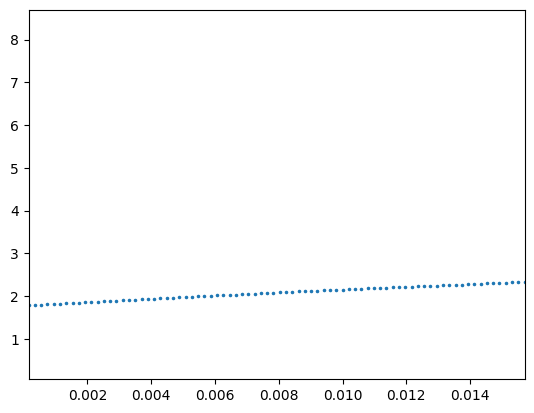

In [260]:

#composite_network.ansatz_time = model 
# ? try reducing number of neurons 
#composite_network = czphi.neural_trainer_time_optimal_cz(nl1 = 2, nu1 = 45, nl2 = 9, \
#    nu2 = 300, beta_control = 1.95, time_bounds = [5.5/cfn.rabi, 8.5/cfn.rabi], beta_time = 2.05)

#print(composite_network.gatetime_prediction)
plt_range = [5e-5*torch.pi, 0.005*torch.pi] 
angle_list = torch.linspace(plt_range[0], plt_range[1], 80).reshape(80, 1)

composite_network(angle_list) 
#composite_network(angle_list) 
#sorted_, _ = torch.sort(composite_network.gatetime_prediction, dim = 0)
#sorted_angle, _ = torch.sort(desired_angle, dim = 0)
plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*cfn.rabi, s=2.4)
#plt.scatter(sorted_angle.detach().numpy(), sorted_.detach().numpy()*cfn.rabi, s=2.4)

x_arr = [0.05847605202762446, 0.09368133926144129, 0.02553674111901877, 0.12202160567522635, 0.16003611609405566, 0.24413213708770543, 0.3608541207127307, 0.4828156660963421, 0.5925537648106403, 0.6828254544699208, 0.8650083393362422, 0.9700092097167208, 1.0899796914958313, 1.2832984815261785, 1.3989175729994532, 1.5187260724968614, 1.6395984551609901, 1.7358666172693598, 1.8735801205673441, 1.9866724565710312, 2.09323202133587, 2.183381753405148, 2.3227001711518453, 2.453807876555414, 2.5711061215651685, 2.6829292712776533, 2.823922793003788, 2.9481701092904693, 3.038817560173, 3.146991745070998]

y_arr = [3.5941027524177587, 3.938737981277658, 3.0640654170130324, 4.168456623425607, 4.45059841976562, 4.910650536663227, 5.254585868573394, 5.596251576465882, 5.853283139036311, 5.99639367713345, 6.283705918720844, 6.414477894295825, 6.538290393011855, 6.743657312659085, 6.849114251113775, 6.935138852908203, 7.030197134928828, 7.0991086362566005, 7.186596171618144, 7.233695935987047, 7.297650376324034, 7.3382753032677375, 7.397785785092296, 7.440760914421173, 7.482294746164857, 7.524834368602767, 7.536685144221717, 7.583423794921136, 7.583418199201171, 7.62755164256274]
plt.scatter(x_arr,y_arr, s = 2.4)
# 6.41
plt.xlim(plt_range[0], plt_range[1])
plt.ylim(0.05, 8.7)

print(composite_network.gatetime_prediction.T)
#print((sorted_)*2*4*torch.pi)

In [ ]:
print(nn_solver_1)

In [ ]:
# Code to plot the time 
angle_list = torch.linspace(0, 0.1*np.pi, czphi.angle_batch).reshape(czphi.angle_batch, 1)
composite_network(angle_list)
print(composite_network.gatetime_prediction)
plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*(np.pi))


In [ ]:
# code to plot variance in fidelity 
import schsolve

angle_list = torch.linspace(0.0, 1*np.pi, czphi.angle_batch).reshape(czphi.angle_batch, 1)

instance = schsolve.schsolver(czphi.system, 1, mode = "single").to(device)

for i in angle_list: 

    i = i.reshape(1,1)
    #print(cfn.czp_gate_stack(i).shape)
    #print(composite_network(i.reshape(1,1)).shape)
    pred_outputs_detuning = (composite_network(i).\
        select(1,0))*(composite_network.range_detuning[1] - composite_network.range_detuning[0]) + composite_network.range_detuning[0]
    print(pred_outputs_detuning.shape)
    instance.hamiltonian.rabi_tensored["pulse 0"] = instance.hamiltonian.rabi_tensored["pulse 1"]\
    = cfn.const_then_zero_tensor(cfn.rabi, composite_network.gatetime_prediction)
    
    instance.hamiltonian.det_tensored["pulse 0"] = instance.hamiltonian.det_tensored["pulse 1"]\
        = czphi.list_to_fn_tensor_var_gatetime(pred_outputs_detuning, composite_network.gatetime_prediction, czphi.time_steps)
    
    # gatetime should now be max of czphi
    
    time_arr_ = torch.linspace(0, 1.0, czphi.time_steps, device = device)*composite_network.gatetime_prediction.max()
    #print(time_arr_.requires_grad)

    sol_intrm = reduce_r_dim_2q_vector(tdf.odeint(instance,\
                                torch.eye(9).reshape(1,9,9), time_arr_, 
                                method = 'rk4')[-1], angle_batch = 1)
    #'rk4'
    #print(sol_intrm.is_cuda)
    solution = correction_1q(sol_intrm, angle_batch = 1) 
        #print(cfn.czp_gate_stack(i).shape)
    fidelity = (cfn.unitary_infidelity_array(cfn.czp_gate_stack(i), solution, nqbits = 2))
    print(fidelity)

#    cfn.unitary_infidelity_array(cfn.czp_gate_stack(i).reshape(1,1), composite_network(i).reshape(1,1))

# Code to save the optimization results
Allows us to save and load results later e.g. to further optimize a partially converged network or to use some network as the initial guess for a different optimization problem. 

In [102]:

#soln = torch.tensor(soln)
filename = "data/final_models/0.05pi_to_0.1pi"
dict_ = cfn._optim_to_dict(composite_network, \
    'n/a', desired_angle, 'n/a', [nn_solver_1, nn_solver_2], loss_val = 'n/a')

torch.save(dict_, filename)

# Sequential partial training of random networks
Trains randomly initialized networks for 50 epochs and saves the results. 

In [ ]:
n_networks = 500
n_iterations = 11

custom_domain = [0.3*torch.pi, 1.0*torch.pi] 
desired_angle = torch.tensor([[0.5*torch.pi]])

for net_id in range(n_networks):
  
  init_matrix = czphi.init_matrix.detach().clone() 
  t_pi_pred = torch.zeros(1)

  while t_pi_pred.item() > 7.64 or t_pi_pred.item() < 7.58:

    composite_network = czphi.neural_trainer_time_optimal_cz(nl1 = 3, nu1 = 45, nl2 = 14, \
    nu2 = 300, beta_control = 1.95, time_bounds = [4.05/cfn.rabi, 9.5/cfn.rabi], beta_time = 2.05)
    tb = composite_network.time_bounds 
    composite_network(torch.tensor([[torch.pi]]))
    t_pi_pred = composite_network.gatetime_prediction

  nn_solver_1 = torch.optim.Adam(composite_network.ansatz_time.parameters(), lr=1e-4, \
    eps=1e-5, amsgrad = True) 
  nn_solver_2 = torch.optim.Adam(composite_network.ansatz_control.parameters(), lr=1e-4,\
    eps=1e-5, amsgrad = True)

  for epoch_ in range(n_iterations):

    #if epoch_ %1e1 == 0:
    desired_angle = torch.rand(czphi.angle_batch, 1, device=device) * \
                (custom_domain[1] - custom_domain[0]) + \
                custom_domain[0]

  
    soln, loss, dict_ = trainer(composite_network, nn_solver_1, nn_solver_2, input_tensor = desired_angle, \
        epoch = epoch_, multiplier = 1e-4, scheduler = [False], init_matrix = init_matrix, print_ = False) # for the composite NN 
    
    if epoch_%25 == 0:
      print(dict_)

    if epoch_ % 2 == 0:
        print((loss, net_id, dict_))
  
  if (dict_["infidelity term"] < 0.04):
    print('okay!')
    filename = "data/seq_small/partial_sec_"+str(net_id+7)
    dict_ = cfn._optim_to_dict(composite_network, \
      soln, desired_angle, 'n/a', [nn_solver_1, nn_solver_2], loss)

    torch.save(dict_, filename)
  

In [ ]:
# code to further train a network w a certain id 
id_ = '7'
filename = "data/seq_small/partial_sec_"+id_
load_dict = torch.load(filename)
composite_network = load_dict["network"].to(device)
#composite_network._aux_tensor = composite_network._aux_tensor.to(device)
nn_solver_1 = load_dict["solver"][0]
nn_solver_2 = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)
init_matrix = czphi.init_matrix 


In [ ]:
nn_solver_ = torch.optim.Adam(composite_network.parameters(), lr=1e-6, eps=1e-4, amsgrad = True, weight_decay = 1e-4) 

for g in nn_solver_1.param_groups:
    g['lr'] = 5e-5

for g in nn_solver_2.param_groups:
    g['lr'] = 5e-4

for epoch_ in range(int(2e4)):
    
    desired_angle = torch.rand(czphi.angle_batch, 1, device=device) * \
                (custom_domain[1] - custom_domain[0]) + \
                custom_domain[0]
    
    soln, loss, dict_ = trainer(composite_network, nn_solver_1 = nn_solver_1, nn_solver_2 = nn_solver_2,
         input_tensor = desired_angle, \
        epoch = epoch_, multiplier = 1e-3, scheduler = [False], init_matrix = init_matrix, print_ = False) # for the composite NN 
    if epoch_%5 == 0: 
        print(loss, dict_)



In [ ]:
# Code to analyse the sequential training folder
# generated via cluster_run_sequential.py

import os 
 
directory_etc = 'data/seq_small/'
iter_list = os.listdir(directory_etc)
loss_total = []
num_list = []
for i in iter_list:  

    dict_ = torch.load(directory_etc + i)
    loss_total.append(dict_['loss_instance'])
    num_list.append(i)

print(loss_total.index(min(np.array(loss_total))))